In [ ]:
!pip install geopandas

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import geopandas as gpd
import os
import glob
import re

In [4]:
POI_DIR = '/content/drive/MyDrive/SmartSite/Step 1: Extract/Results_CSV'
geojson_files = glob.glob(os.path.join(POI_DIR, "*.geojson"))

print(f"Tìm thấy {len(geojson_files)} file GeoJSON.")

Tìm thấy 3 file GeoJSON.


In [5]:
gdf_list = []
for file in geojson_files:
    try:
        gdf = gpd.read_file(file)
        filename = os.path.basename(file).lower()
        if 'hcm' in filename or 'hochiminh' in filename:
            gdf['City'] = 'HCM'
        elif 'hanoi' in filename:
            gdf['City'] = 'HaNoi'
        elif 'danang' in filename:
            gdf['City'] = 'DaNang'
        else:
            gdf['City'] = 'Unknown'
        gdf_list.append(gdf)
    except Exception as e:
        pass

raw_poi_gdf = pd.concat(gdf_list, ignore_index=True)
print(f"Đã gộp xong! Tổng số POI thô: {raw_poi_gdf.shape[0]} dòng.")

Đã gộp xong! Tổng số POI thô: 52983 dòng.


In [6]:
pd.set_option('display.max_rows', None)

type_counts = raw_poi_gdf['type'].value_counts()

type_summary = pd.DataFrame({
    'Số lượng': type_counts,
    'Tỉ lệ (%)': round((type_counts / len(raw_poi_gdf)) * 100, 2)
})

print(type_summary)

pd.reset_option('display.max_rows')

                                  Số lượng  Tỉ lệ (%)
type                                                 
highway_bus_stop                     11590      21.87
building_residential                  6032      11.38
restaurant                            4936       9.32
cafe                                  4272       8.06
building_apartments                   4211       7.95
landuse_residential                   3867       7.30
school                                3535       6.67
shop_convenience                      3115       5.88
leisure_park                          1830       3.45
Khác                                  1343       2.53
landuse_commercial                    1227       2.32
kindergarten                           974       1.84
building_yes                           885       1.67
fast_food                              813       1.53
shop_supermarket                       656       1.24
marketplace                            580       1.09
bar                         

In [7]:
def categorize_poi_features(row):
    name = str(row['name']).lower().strip()
    osm_type = str(row['type']).lower().strip()

    if name in ['nan', 'none', 'n/a', 'null', '']:
        name = 'n/a'

    # Rule 1: Sub-structure filter
    sub_pattern = r'^(khu\s+|tòa\s+|khoa\s+|dãy\s+|cổng\s+|nhà\s+[a-z0-9]$|block\s+)'
    if name != 'n/a' and re.search(sub_pattern, name):
        return 'Sub_Building'

    # Rule 2: OSM tag TRƯỚC
    if osm_type in ['highway_bus_stop', 'bus_station', 'railway_station',
                    'railway_subway_entrance', 'ferry_terminal',
                    'highway_traffic_signals;bus_stop']:
        return 'Transport'

    if osm_type in ['restaurant', 'cafe', 'fast_food', 'bar', 'food_court',
                    'marketplace', 'internet_cafe', 'restaurant;karaoke',
                    'pub;bar', 'pharmacy;cafe', 'bank;cafe']:
        return 'Food'

    if osm_type in ['shop_convenience', 'shop_supermarket', 'shop_mall',
                    'shop_department_store', 'landuse_retail', 'building_retail']:
        return 'Commercial'

    if osm_type in ['leisure_park', 'leisure_water_park', 'leisure_pitch',
                    'leisure_playground', 'leisure_fitness_centre',
                    'leisure_trampoline_park', 'cinema', 'library',
                    'theatre', 'studio', 'events_venue']:
        return 'Leisure'

    if osm_type in ['school', 'kindergarten', 'university', 'college',
                    'language_school', 'driving_school', 'music_school',
                    'prep_school', 'driver_training', 'building_university',
                    'building_school', 'dancing_school']:
        return 'Education'

    if osm_type in ['office', 'bank', 'townhall', 'research_institute',
                    'police', 'building_office', 'building_commercial',
                    'landuse_commercial', 'building_government',
                    'building_civic', 'post_office', 'building_government_office',
                    'consultant', 'research_centre', 'courthouse',
                    'community_centre', 'conference_centre', 'exhibition_centre']:
        return 'Office'

    if osm_type in ['landuse_residential', 'building_apartments',
                    'building_residential', 'building_house',
                    'building_terrace', 'hado garden villas']:
        return 'Residential'

    # Rule 3: Name-based
    if name != 'n/a':
        if re.search(r'(\btrường\b|tiểu học|mầm non|thcs|thpt|đại học|cao đẳng|học viện|academy|school|university|college|kindergarten)', name):
            return 'Education'
        if re.search(r'(nhà hàng|quán ăn|restaurant|buffet|food court)', name):
            return 'Food'
        if re.search(r'(cafe|cà phê|coffee|quán cà|trà sữa|milk tea)', name):
            return 'Food'
        if re.search(r'(siêu thị|supermarket|vinmart|coopmart|big c|lotte)', name):
            return 'Commercial'
        if re.search(r'(công viên|park\b)', name):
            return 'Leisure'
        if re.search(r'(công ty|văn phòng|tập đoàn|ngân hàng|trụ sở|chi nhánh|ltd|company|bank|ubnd|ủy ban|sở|cục|bộ\b|viện|bảo hiểm)', name):
            return 'Office'
        if re.search(r'(chung cư|khu dân cư|kđt|khu đô thị|nhà ở|căn hộ|apartment|vinhomes)', name):
            return 'Residential'

    return 'Other'

# 1. Áp dụng Pipeline phân loại
raw_poi_gdf['Category_Clean'] = raw_poi_gdf.apply(categorize_poi_features, axis=1)

# 2. Làm sạch dữ liệu không gian
poi_gdf = raw_poi_gdf.dropna(subset=['geometry']).copy()

# 3. Lọc bỏ nhiễu (Xóa nhóm Sub_Building)
poi_gdf = poi_gdf[poi_gdf['Category_Clean'] != 'Sub_Building']

# 4. Đồng bộ hệ tọa độ (CRS) về chuẩn WGS84
if poi_gdf.crs is None or poi_gdf.crs.to_string() != 'EPSG:4326':
    poi_gdf = poi_gdf.set_crs('EPSG:4326', allow_override=True)

print("📊 BÁO CÁO PHÂN BỔ DỮ LIỆU (CLASS DISTRIBUTION):")
print(poi_gdf['Category_Clean'].value_counts())


for category in ['Education', 'Office', 'Residential', 'Other']:
    print(f"\n--- Mẫu dữ liệu nhóm: {category} ---")
    sample_df = poi_gdf[poi_gdf['Category_Clean'] == category][['name', 'type', 'Category_Clean', 'City']]

    if len(sample_df) > 15:
        display(sample_df.sample(15))
    else:
        display(sample_df)

📊 BÁO CÁO PHÂN BỔ DỮ LIỆU (CLASS DISTRIBUTION):
Category_Clean
Residential    13400
Transport      11568
Food           11197
Education       5218
Commercial      3906
Office          3144
Leisure         2019
Other           1275
Name: count, dtype: int64

--- Mẫu dữ liệu nhóm: Education ---


,name,type,Category_Clean,City
11409,Trường Tiểu học An Hảo,school,Education,HCM
35990,Trường Tiểu học Vĩnh Tuy,school,Education,HaNoi
49879,Trường Mầm non xã Xuy Xá,kindergarten,Education,HaNoi
35958,Trường Tiểu học Trung Phụng,school,Education,HaNoi
10688,Trường Ngoại Ngữ Pixar - Cơ Sở 2,school,Education,HCM
31148,Trường Trung học cơ sở Thạch Xá,school,Education,HaNoi
37099,N/A,school,Education,HaNoi
37103,Trường Tiểu học Nguyễn Thị Minh Khai,school,Education,HaNoi
38974,Trường Mầm non Ban Mai Xanh,kindergarten,Education,HaNoi
32859,Mầm non NASA,kindergarten,Education,HaNoi



--- Mẫu dữ liệu nhóm: Office ---


,name,type,Category_Clean,City
39394,Ban quản lý Dự án Đầu tư Xây dựng phường Tương...,landuse_commercial,Office,HaNoi
10569,Cục Quản lý Xuất nhập cảnh Thành phố Hồ Chí Minh,Khác,Office,HCM
11197,TMA Tower - Lab 6,building_office,Office,HCM
9066,Ủy ban nhân dân xã Vĩnh Lộc,townhall,Office,HCM
13235,Cục thuế tỉnh Đồng Nai,landuse_commercial,Office,HCM
24990,UBND huyện Thủ Thừa,building_yes,Office,HCM
38895,Tập đoàn Giống cây trồng Việt Nam,building_office,Office,HaNoi
26671,Ủy ban nhân dân phường Bình Phú,townhall,Office,HCM
32407,Công Ty Cầu 5 Thăng Long,Khác,Office,HaNoi
26311,Công Ty TNHH Tư Vấn Thiết Kế Và Thi Công Smart...,Khác,Office,HCM



--- Mẫu dữ liệu nhóm: Residential ---


,name,type,Category_Clean,City
27260,N/A,landuse_residential,Residential,HCM
12089,N/A,building_apartments,Residential,HCM
4924,N/A,building_residential,Residential,DaNang
11922,N/A,building_apartments,Residential,HCM
27804,MP6,building_apartments,Residential,HCM
34491,H4,building_apartments,Residential,HaNoi
35618,N/A,building_apartments,Residential,HaNoi
25219,N/A,landuse_residential,Residential,HCM
4241,N/A,building_residential,Residential,DaNang
12222,Lô N,building_apartments,Residential,HCM



--- Mẫu dữ liệu nhóm: Other ---


,name,type,Category_Clean,City
49590,N/A,Khác,Other,HaNoi
10701,Toà nhà Empress Tower,Khác,Other,HCM
33130,Quỹ Tín dụng Trang Hạ,Khác,Other,HaNoi
37936,Nhà xuất bản Thống kê,building_yes,Other,HaNoi
211,N/A,Khác,Other,DaNang
49662,Nơi tuyển quân xã Nghĩa trụ,Khác,Other,HaNoi
11028,Prosperous Living Investment,Khác,Other,HCM
32528,Đại sứ quán Colombia,Khác,Other,HaNoi
678,Nissan,shop_car,Other,DaNang
28082,Kim Lan,building_yes,Other,HCM


In [8]:
print(f"Số POI: {len(poi_gdf)}")
print(f"Cột hiện có: {poi_gdf.columns.tolist()}")
print(poi_gdf['type'].value_counts().head(10)
      if 'type' in poi_gdf.columns
      else poi_gdf.dtypes)
display(poi_gdf.head(3))

Số POI: 51727
Cột hiện có: ['name', 'type', 'lat', 'lon', 'geometry', 'City', 'Category_Clean']
type
highway_bus_stop        11240
building_residential     6024
restaurant               4936
cafe                     4272
building_apartments      3781
landuse_residential      3578
school                   3523
shop_convenience         3114
leisure_park             1813
Khác                     1310
Name: count, dtype: int64


,name,type,lat,lon,geometry,City,Category_Clean
0,Trường Tiểu Học Quang Trung,school,16.089844,108.245335,POINT (108.24534 16.08984),DaNang,Education
1,N/A,school,16.079051,108.231661,POINT (108.23166 16.07905),DaNang,Education
2,Trường Tiểu Học Hai Bà Trưng,school,16.081045,108.229183,POINT (108.22918 16.08105),DaNang,Education


/tmp/ipykernel_3939/2997083274.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_types.values, y=top_types.index, palette='magma')


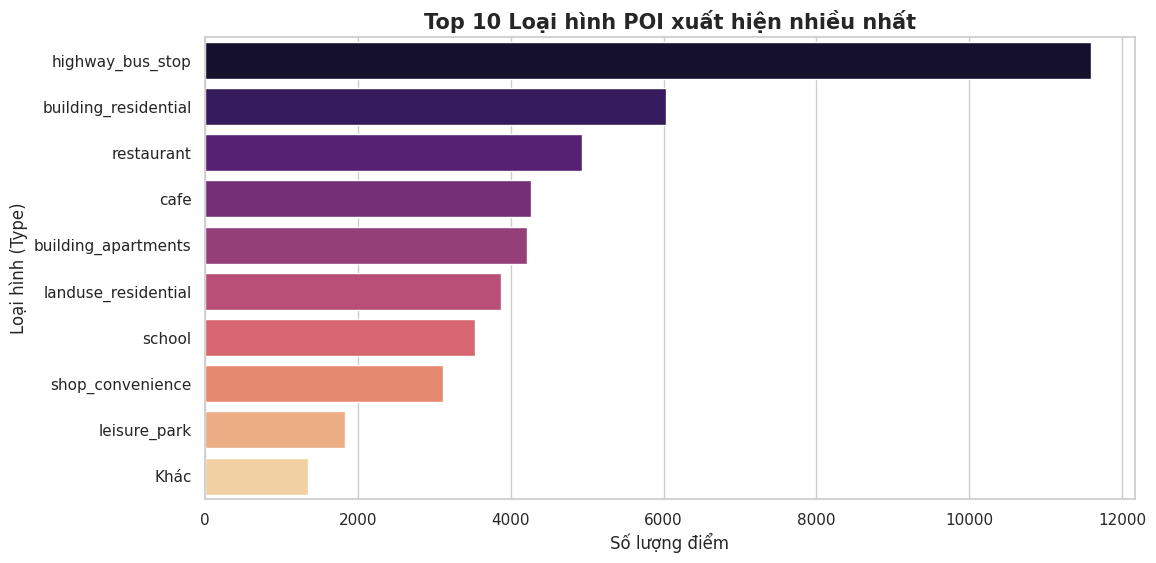

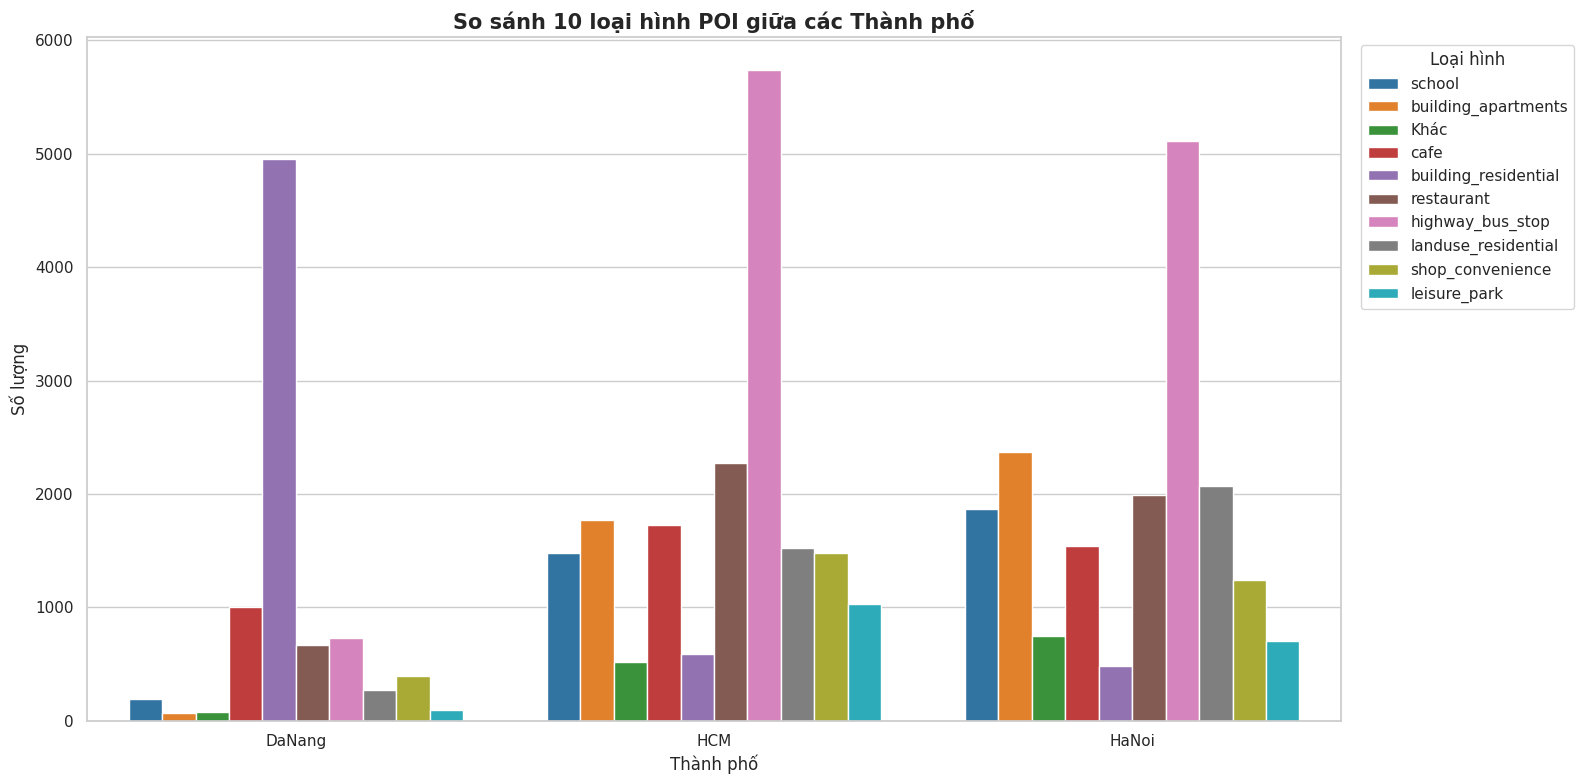

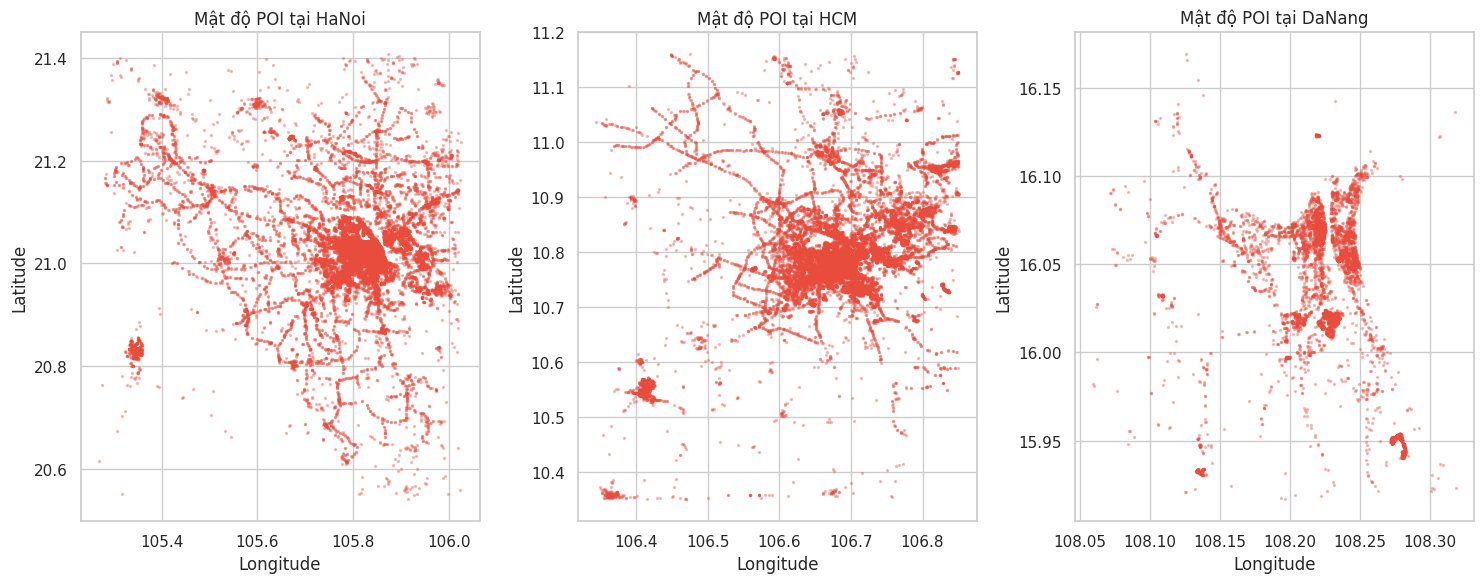

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# 1. Biểu đồ Top 10 loại hình POI phổ biến nhất (Toàn quốc)
if 'type' in raw_poi_gdf.columns:
    plt.figure(figsize=(12, 6))
    top_types = raw_poi_gdf['type'].value_counts().head(10)
    sns.barplot(x=top_types.values, y=top_types.index, palette='magma')

    plt.title('Top 10 Loại hình POI xuất hiện nhiều nhất', fontsize=15, fontweight='bold')
    plt.xlabel('Số lượng điểm')
    plt.ylabel('Loại hình (Type)')
    plt.show()

# 2. Biểu đồ so sánh cơ cấu POI giữa các Thành phố
if 'type' in raw_poi_gdf.columns:
    top_10_types = raw_poi_gdf['type'].value_counts().head(10).index
    df_filtered = raw_poi_gdf[raw_poi_gdf['type'].isin(top_10_types)]

    plt.figure(figsize=(16, 8))
    sns.countplot(data=df_filtered, x='City', hue='type', palette='tab10')

    plt.title('So sánh 10 loại hình POI giữa các Thành phố', fontsize=15, fontweight='bold')
    plt.legend(title='Loại hình', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.xlabel('Thành phố')
    plt.ylabel('Số lượng')
    plt.tight_layout()
    plt.show()

# 3. Biểu đồ mật độ phân bổ (Spatial Density - Scatter plot)
plt.figure(figsize=(15, 6))
cities = [c for c in ['HaNoi', 'HCM', 'DaNang'] if c in raw_poi_gdf['City'].unique()]

for i, city in enumerate(cities, 1):
    plt.subplot(1, 3, i)
    city_data = raw_poi_gdf[raw_poi_gdf['City'] == city]

    # Sử dụng scatter plot với độ trong suốt (alpha) để thấy các vùng đậm đặc
    plt.scatter(city_data.geometry.x, city_data.geometry.y,
                s=2, alpha=0.3, c='#e74c3c')

    plt.title(f'Mật độ POI tại {city}', fontsize=12)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')

plt.tight_layout()
plt.show()

In [ ]:
output_poi_path = '/content/drive/MyDrive/SmartSite/Step 2: Data Processing/Coffee_Tea_Data_POI.geojson'

poi_gdf.to_file(output_poi_path, driver='GeoJSON')

print(f"File đã lưu tại: {output_poi_path}")